<a href="https://colab.research.google.com/github/DivyankBaluni/HousePricePrediction/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Imports

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

###Task 1 - **Data Loading and Exploration**

In [35]:
df = pd.read_csv("Housing.csv")
print("Dataset Loaded successfully.")

Dataset Loaded successfully.


In [36]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [37]:
rows, cols = df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 545
Columns: 13


In [38]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [39]:
target = "price"
print("Target Column:", target)

Target Column: price


In [40]:
features = df.drop("price", axis=1).columns
print("Feature Columns:")
print(features.tolist())

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [41]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [42]:
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


###Task 2 - **Data Cleaning**

In [43]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [44]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df = df.drop_duplicates()
print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (545, 13)


In [45]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [46]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [47]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

In [48]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

In [49]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

In [51]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


###Task 3 - **Model Building**

In [52]:
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


####Model-1: **Linear Regression**

In [53]:
lr_model = LinearRegression() #Model creation

In [54]:
lr_model.fit(X_train, y_train) #Model training

LinearRegression()

In [55]:
print("Training R²:", lr_model.score(X_train, y_train))
print("Testing R² :", lr_model.score(X_test, y_test))

Training R²: 0.6859438988560158
Testing R² : 0.6529242642153185


In [56]:
lr_predictions = lr_model.predict(X_test)

In [57]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE : 970043.4039201637
RMSE: 1324506.9600914384
R² Score: 0.6529242642153185


####Model-2: **Random Forest**

In [58]:
rf_model = RandomForestRegressor(
    n_estimators=100, random_state=42
)

In [59]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [60]:
rf_predictions = rf_model.predict(X_test)

In [61]:
print("Training R²:", rf_model.score(X_train, y_train))
print("Testing R² :", rf_model.score(X_test, y_test))

Training R²: 0.9498289117904977
Testing R² : 0.6114024924156645


In [62]:
rf_mae = mean_absolute_error(y_test,rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 1022560.0527522935
RMSE: 1401496.8425384816
R² Score: 0.6114024924156645


####**Comparison**

In [63]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


###Task 4 - **Data Visualization**

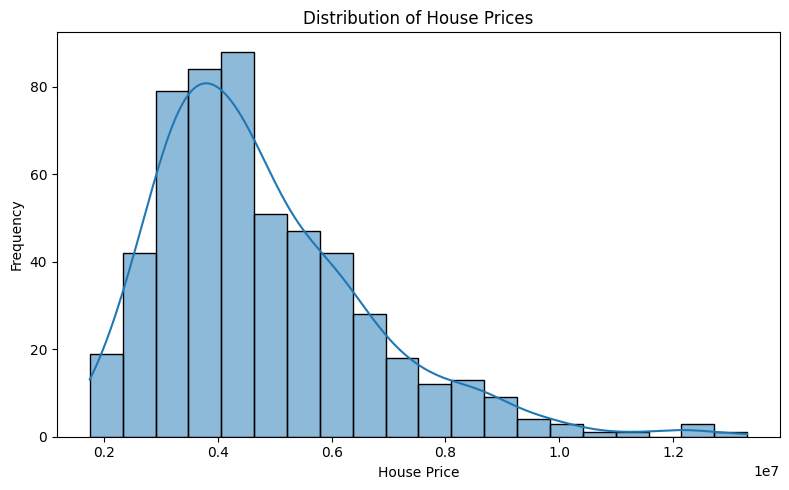

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=20, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

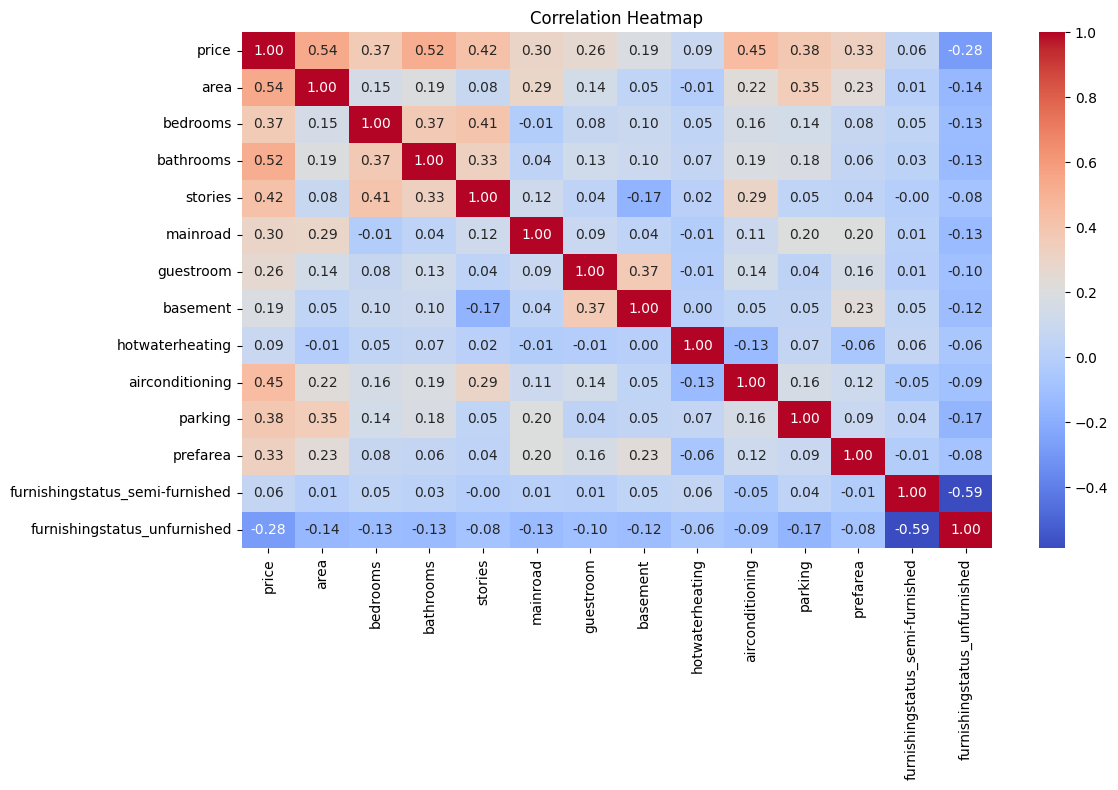

In [65]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

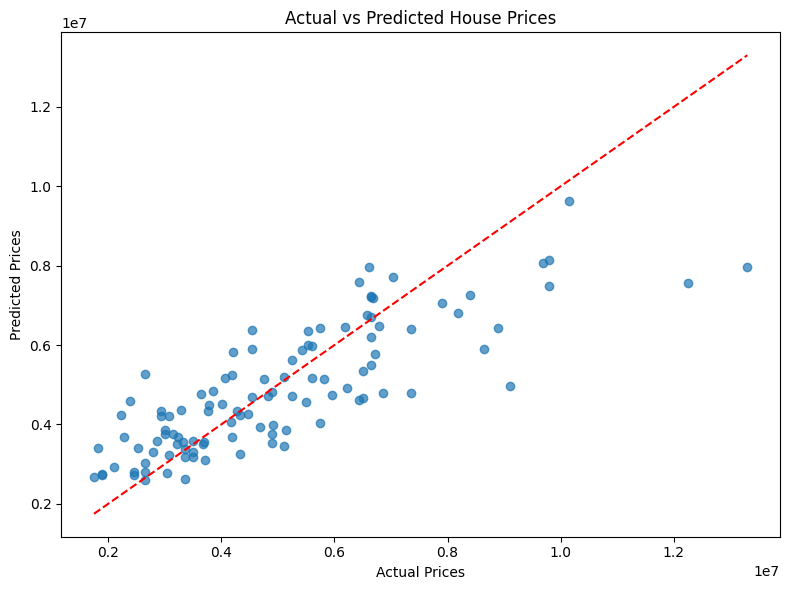

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

###Task 5 - **Insights and Summary**

The analysis revealed that features such as house area, number of bathrooms, number of stories, and amenities like air conditioning have a significant influence on property prices.

After training and evaluating two machine learning models, Linear Regression achieved the best performance with an R² score of approximately 0.65, meaning it could explain around 65% of the variation in house prices.
This indicates that the model provides reasonably reliable estimates while still leaving room for improvement.

One interesting observation was that the Linear Regression model outperformed the Random Forest model, suggesting that the relationships between the housing features and prices are relatively linear in nature.

The distribution of house prices also showed that most properties fall within the mid-price range, while very expensive houses are less common. Based on these findings, real estate businesses should prioritize factors such as property size, bathrooms, and key amenities when pricing or marketing homes, as these features appear to contribute most strongly to a property's market value.


## Project Conclusion

This project successfully developed and evaluated machine learning models for predicting house prices. After preprocessing the data and comparing multiple regression techniques, Linear Regression achieved the best performance with an R² score of approximately 0.65. The project demonstrates how data-driven approaches can assist buyers, sellers, and real estate businesses in making more informed pricing decisions.